# Нелинейные модели: предсказание **аритмии**

Целевая переменная: `target_arrhythmia` (1 - аритмия, 0 - нет). Признаки - те же, что в исходном пайплайне по инфаркту: ECG-признаки и возраст.

При подборе гиперпараметров используется **F-beta** с beta=3 (сильнее штрафуем пропуск аритмии). После обучения порог по вероятности класса «1» выбирается **на валидации** так, чтобы максимизировать F2 меру.

In [4]:
!pip install catboost -q
!pip install xgboost -q

## Импорты и общие настройки

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    fbeta_score,
    make_scorer,
    confusion_matrix,
    recall_score,
    precision_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

random_state = 42
TARGET_COL = "target_arrhythmia"

## Загрузка данных, создание колонок с признаками и таргетами

In [6]:
df = pd.read_csv("2025_11_26_eda_final_ecg_data.csv", low_memory=False)
print(df.shape)

(9793, 42)


In [7]:
categorical_columns = ["heart_axis_norm", "V1_pathological_Q"]
numeric_columns = [
    "age", "I_prop_censored", "II_wavelet_entropy", "II_SNR_dB", "III_PSD_std_freq",
    "III_wavelet_E2", "AVR_RMSSD", "AVR_STFT_energy", "AVR_SNR_dB", "AVR_prop_censored",
    "AVL_STFT_energy", "AVL_SNR_dB", "AVF_SNR_dB", "V1_RMSSD", "V1_STFT_energy",
    "V1_wavelet_entropy", "V1_SNR_dB", "V2_STFT_energy", "V2_SNR_dB", "V2_Q_wave_amp",
    "V3_STFT_energy", "V3_SNR_dB", "V3_Q_wave_amp", "V4_STFT_energy", "V4_SNR_dB",
    "V5_SNR_dB", "V5_prop_censored", "V5_Q_wave_amp", "V6_STFT_energy", "V6_SNR_dB",
    "V6_prop_censored", "meanRR_global", "V3_PSD_mean_freq", "V5_PSD_std_freq",
    "AVF_wavelet_E5", "I_wavelet_E5", "I_wavelet_entropy",
]
df["target_patology"] = 1 - df["target_norm"]
target_columns = ["target_patology", "target_norm", "target_arrhythmia", "target_infarction"]

In [8]:
df.head()

,heart_axis_norm,V1_pathological_Q,age,I_prop_censored,II_wavelet_entropy,II_SNR_dB,III_PSD_std_freq,III_wavelet_E2,AVR_RMSSD,AVR_STFT_energy,AVR_SNR_dB,AVR_prop_censored,AVL_STFT_energy,AVL_SNR_dB,AVF_SNR_dB,V1_RMSSD,V1_STFT_energy,V1_wavelet_entropy,V1_SNR_dB,V2_STFT_energy,V2_SNR_dB,V2_Q_wave_amp,V3_STFT_energy,V3_SNR_dB,V3_Q_wave_amp,V4_STFT_energy,V4_SNR_dB,V5_SNR_dB,V5_prop_censored,V5_Q_wave_amp,V6_STFT_energy,V6_SNR_dB,V6_prop_censored,meanRR_global,V3_PSD_mean_freq,V5_PSD_std_freq,AVF_wavelet_E5,I_wavelet_E5,I_wavelet_entropy,target_norm,target_arrhythmia,target_infarction,target_patology
0,1,0,56.0,0.007,5.419053,24.614638,10.744334,0.199637,55.565277,0.000049,11.494849,0.005,0.000036,5.219391,8.615288,24.748737,0.000071,5.395219,34.069058,0.000250,29.086629,0.061861,0.000076,27.857958,0.054091,0.000050,25.957710,37.043980,0.011,0.059730,0.000063,41.418078,0.001,932.814815,12.222654,6.369762,0.076317,0.673067,5.789799,1,0,0,0
1,1,0,19.0,0.011,4.863514,11.281906,6.079428,1.519053,353.647659,0.000205,13.448662,0.004,0.000072,11.842842,10.300809,62.289646,0.000362,5.637168,13.634131,0.001357,30.604034,0.072253,0.000926,26.778794,0.097217,0.000516,36.819489,30.670310,0.012,0.102146,0.000225,22.411185,0.012,1235.629960,5.687558,9.253184,1.437292,0.888177,5.132125,1,0,0,0
2,1,0,37.0,0.013,4.893569,25.876320,6.719915,0.305148,72.543091,0.000079,23.365255,0.008,0.000059,20.288585,25.306726,26.457513,0.000074,5.683308,32.862776,0.000120,42.750413,0.067168,0.000153,20.615563,0.095022,0.000107,31.332773,18.945366,0.012,0.065056,0.000061,18.912740,0.011,940.277778,12.888998,8.601877,0.098511,1.169473,5.820171,1,0,0,0
3,1,0,24.0,0.011,5.417974,11.698055,7.043775,8.348671,36.431754,0.000411,13.678661,0.011,0.000313,10.103433,10.940353,34.785054,0.000213,5.324780,13.658337,0.000971,18.461447,0.121226,0.001628,24.705495,0.204138,0.001651,14.261899,15.788369,0.004,0.182474,0.000511,13.302702,0.003,800.542929,7.669082,7.352540,3.043082,0.954254,5.472135,1,0,0,0
4,1,0,19.0,0.004,5.682799,8.962398,7.207289,3.344558,88.443328,0.000129,10.586666,0.006,0.000047,7.062302,8.157117,56.174332,0.000110,5.674402,14.866878,0.000622,21.145494,0.087013,0.000230,17.470063,0.095123,0.000298,18.899305,20.769346,0.013,0.092893,0.000175,24.289349,0.014,901.719697,8.957262,7.656655,1.503427,0.603274,5.884295,1,0,0,0


## Формирование X и y, разбиение на train / validation / test

In [9]:
X = df.drop(columns=target_columns)
y = df[TARGET_COL]
assert X.shape[1] == len(categorical_columns) + len(numeric_columns)

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=random_state, stratify=y_temp)
del X_temp, y_temp

n = len(X)
print(f"Обучение: {len(X_train)} ({100 * len(X_train) / n:.1f}%)")
print(f"Валидация: {len(X_val)} ({100 * len(X_val) / n:.1f}%)")
print(f"Тест: {len(X_test)} ({100 * len(X_test) / n:.1f}%)")

Обучение: 6267 (64.0%)
Валидация: 1567 (16.0%)
Тест: 1959 (20.0%)


## Доли классов (аритмия = 1)

In [11]:
print("Train:\n", y_train.value_counts())
print(f"Доля положительного класса (train): {y_train.mean():.3f}")
print("\nTest:\n", y_test.value_counts())
print(f"Доля положительного класса (test): {y_test.mean():.3f}")

Train:
 target_arrhythmia
0    4753
1    1514
Name: count, dtype: int64
Доля положительного класса (train): 0.242

Test:
 target_arrhythmia
0    1486
1     473
Name: count, dtype: int64
Доля положительного класса (test): 0.241


## Масштабирование числовых колонок

In [12]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_columns])
X_val_num = scaler.transform(X_val[numeric_columns])
X_test_num = scaler.transform(X_test[numeric_columns])

X_train_scaled = np.hstack([X_train_num, X_train[categorical_columns]])
X_val_scaled = np.hstack([X_val_num, X_val[categorical_columns]])
X_test_scaled = np.hstack([X_test_num, X_test[categorical_columns]])

## Метрика F2, таблица результатов и подбор порога по вероятности

In [13]:
f2_scorer = make_scorer(fbeta_score, beta=3, pos_label=1)
results_summary = pd.DataFrame(columns=["model", "cv_train_f2", "val_f2", "test_f2", "val_recall", "test_recall", "threshold"])

def add_model_row(name, cv_f2, val_f2, test_f2, val_rec, test_rec, thr):
    global results_summary
    results_summary = pd.concat(
        [
            results_summary,
            pd.DataFrame(
                [{
                    "model": name,
                    "cv_train_f2": cv_f2,
                    "val_f2": val_f2,
                    "test_f2": test_f2,
                    "val_recall": val_rec,
                    "test_recall": test_rec,
                    "threshold": thr,
                }]
            ),
        ],
        ignore_index=True,
    )
# Графики precision / recall / F2 и ошибок в зависимости от порога (класс 1 = аритмия)
def plot_threshold_analysis(results_df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(results_df["threshold"], results_df["precision"], "bo-", label="Precision")
    axes[0, 0].plot(results_df["threshold"], results_df["recall"], "ro-", label="Recall")
    axes[0, 0].set_xlabel("Порог")
    axes[0, 0].set_ylabel("Score")
    axes[0, 0].set_title("Precision и Recall vs порог (аритмия)")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(results_df["recall"], results_df["precision"], "go-")
    axes[0, 1].set_xlabel("Recall")
    axes[0, 1].set_ylabel("Precision")
    axes[0, 1].set_title("PR-кривая (аритмия)")
    axes[0, 1].grid(True)

    axes[1, 0].plot(results_df["threshold"], results_df["fn"], "ro-", label="FN")
    axes[1, 0].plot(results_df["threshold"], results_df["fp"], "bo-", label="FP")
    axes[1, 0].set_xlabel("Порог")
    axes[1, 0].set_ylabel("Количество")
    axes[1, 0].set_title("Ошибки vs порог")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(results_df["threshold"], results_df["f2"], "mo-", label="F2")
    axes[1, 1].set_xlabel("Порог")
    axes[1, 1].set_ylabel("F2")
    axes[1, 1].set_title("F2 vs порог")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

class ThresholdModel:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        proba = self.model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def __getattr__(self, name):
        return getattr(self.model, name)

# Таблица метрик по сетке порогов (порог с максимумом F2 на валидации)
def threshold_table(model, Xv, yv):
    proba = model.predict_proba(Xv)[:, 1]
    rows = []
    for t in np.arange(0.05, 1.0, 0.05):
        pred = (proba >= t).astype(int)
        prec = precision_score(yv, pred, pos_label=1, zero_division=0)
        rec = recall_score(yv, pred, pos_label=1)
        f2 = fbeta_score(yv, pred, beta=3, pos_label=1, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(yv, pred).ravel()
        rows.append({
            "threshold": round(t, 2),
            "precision": prec,
            "recall": rec,
            "f2": f2,
            "fp": fp,
            "tp": tp,
            "fn": fn,
            "tn": tn,
        })
    df_thr = pd.DataFrame(rows)
    best_t = float(df_thr.loc[df_thr["f2"].idxmax(), "threshold"])
    return df_thr, best_t

# Вывод лучших параметров
def report_model(grid_search, model_name: str):
    print("Лучшие параметры:", grid_search.best_params_)
    print("Лучший средний F2 (CV на train):", round(grid_search.best_score_, 4))
    m = grid_search.best_estimator_
    thr_df, thr = threshold_table(m, X_val_scaled, y_val)
    print("Таблица порогов (1 = аритмия):")
    print(thr_df.round(4).to_string(index=False))
    print("Выбранный порог (max F2 на валидации):", thr)
    plot_threshold_analysis(thr_df)

    wrapped = ThresholdModel(m, threshold=thr)
    yvp = wrapped.predict(X_val_scaled)
    ytp = wrapped.predict(X_test_scaled)
    vf2 = fbeta_score(y_val, yvp, beta=3, pos_label=1, zero_division=0)
    tf2 = fbeta_score(y_test, ytp, beta=3, pos_label=1, zero_division=0)
    vrec = recall_score(y_val, yvp, pos_label=1)
    trec = recall_score(y_test, ytp, pos_label=1)
    add_model_row(model_name, grid_search.best_score_, vf2, tf2, vrec, trec, thr)
    return m, wrapped, thr_df, thr

## Базовая модель: логистическая регрессия

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры: {'C': 0.01, 'class_weight': {0: 1, 1: 4}, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший средний F2 (CV на train): 0.7609
Таблица порогов (1 = аритмия):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2421  0.9947 0.7589 1180 377   2    8
      0.10     0.2515  0.9842 0.7622 1110 373   6   78
      0.15     0.2741  0.9736 0.7757  977 369  10  211
      0.20     0.3057  0.9631 0.7926  829 365  14  359
      0.25     0.3343  0.9340 0.7919  705 354  25  483
      0.30     0.3742  0.9103 0.7962  577 345  34  611
      0.35     0.4067  0.8918 0.7968  493 338  41  695
      0.40     0.4428  0.8470 0.7761  404 321  58  784
      0.45     0.4805  0.8127 0.7601  333 308  71  855
      0.50     0.5113  0.7757 0.7376  281 294  85  907
      0.55     0.5374  0.7388 0.7121  241 280  99  947
      0.60     0.5830  0.6860 0.6741  186 260 119 1002
      0.65     0.6177  0.6438 0.6411  151 244 135 1037
 

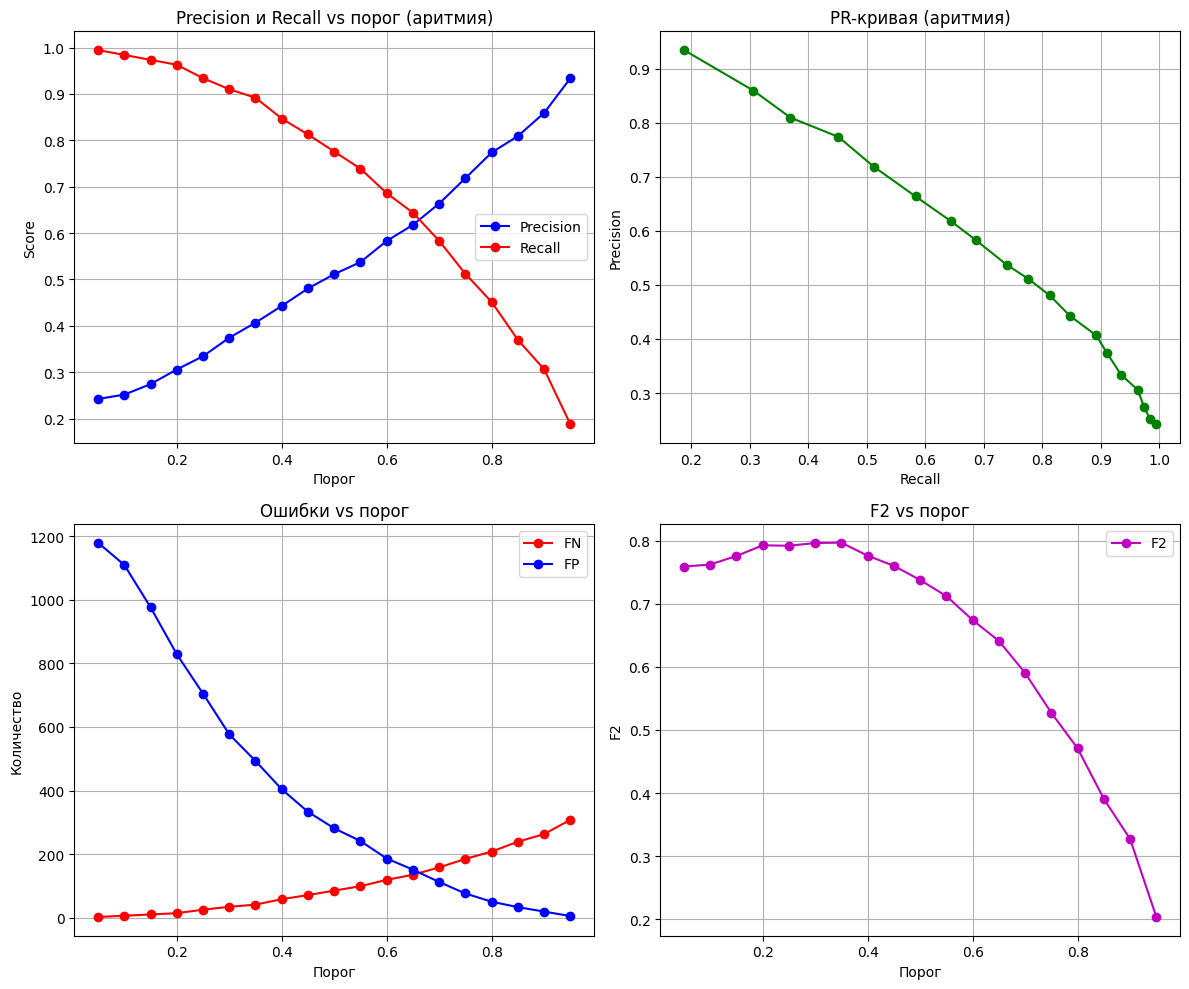

In [14]:
log_reg = LogisticRegression(random_state=random_state, max_iter=2000)
param_grid_lr = {
    "class_weight": [
        {0: 1, 1: 1},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        "balanced",
    ],
    "C": [0.01, 0.1, 0.5, 1, 2, 5],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
gs_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gs_lr.fit(X_train_scaled, y_train)
best_lr, best_lr_thr_model, thr_df_lr, thr_lr = report_model(gs_lr, "LogisticRegression")

## Дерево решений

Fitting 5 folds for each of 3456 candidates, totalling 17280 fits
Лучшие параметры: {'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: 5}, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший средний F2 (CV на train): 0.7816
Таблица порогов (1 = аритмия):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2419  1.0000 0.7613 1188 379   0    0
      0.10     0.2419  1.0000 0.7613 1188 379   0    0
      0.15     0.2419  1.0000 0.7613 1188 379   0    0
      0.20     0.2419  1.0000 0.7613 1188 379   0    0
      0.25     0.4005  0.8602 0.7716  488 326  53  700
      0.30     0.4005  0.8602 0.7716  488 326  53  700
      0.35     0.4005  0.8602 0.7716  488 326  53  700
      0.40     0.4005  0.8602 0.7716  488 326  53  700
      0.45     0.4005  0.8602 0.7716  488 326  53  700
      0.50     0.4005  0.8602 0.7716  488 326  53  700
      0.55     0.4197  0.8206 0.7490  430 311  68  758
      0.60     0.4550  0.7335 0.6912  333 278 101 

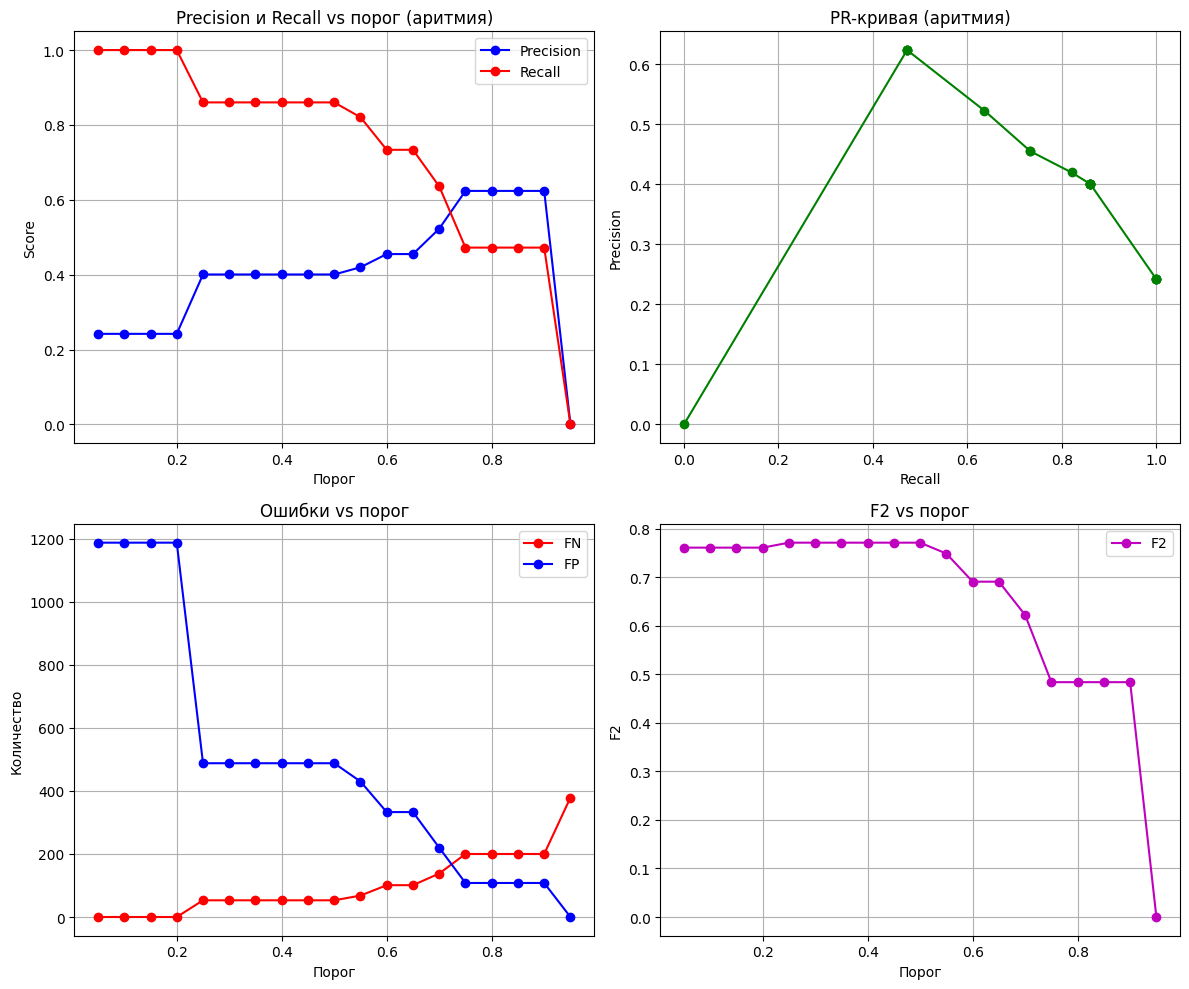

In [15]:
dt = DecisionTreeClassifier(random_state=random_state)
param_grid_dt = {
    "max_depth": [5, 8, 12, 16, 20, None],
    "min_samples_split": [2, 10, 30, 80],
    "min_samples_leaf": [1, 5, 15, 40],
    "max_features": ["sqrt", 0.5, None],
    "ccp_alpha": [0.0, 0.001, 0.01],
    "class_weight": [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}, "balanced"],
}
gs_dt = GridSearchCV(dt, param_grid_dt, scoring=f2_scorer, cv=cv, n_jobs=-1, verbose=1)
gs_dt.fit(X_train_scaled, y_train)
best_dt, best_dt_thr_model, thr_df_dt, thr_dt = report_model(gs_dt, "DecisionTree")

## Случайный лес

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'class_weight': {0: 1, 1: 5}, 'max_depth': 12, 'max_features': 0.6, 'min_samples_leaf': 40, 'min_samples_split': 10, 'n_estimators': 200}
Лучший средний F2 (CV на train): 0.7893
Таблица порогов (1 = аритмия):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2471  1.0000 0.7664 1155 379   0   33
      0.10     0.2694  0.9894 0.7808 1017 375   4  171
      0.15     0.2981  0.9763 0.7954  871 370   9  317
      0.20     0.3262  0.9604 0.8041  752 364  15  436
      0.25     0.3574  0.9420 0.8095  642 357  22  546
      0.30     0.3806  0.9208 0.8064  568 349  30  620
      0.35     0.4086  0.9024 0.8051  495 342  37  693
      0.40     0.4465  0.8918 0.8109  419 338  41  769
      0.45     0.4912  0.8813 0.8164  346 334  45  842
      0.50     0.5248  0.8391 0.7916  288 318  61  900
      0.55     0.5572  0.7836 0.7530  236 297  82  952
      0.60     0.6081  0.7493 0.7323  183 284  9

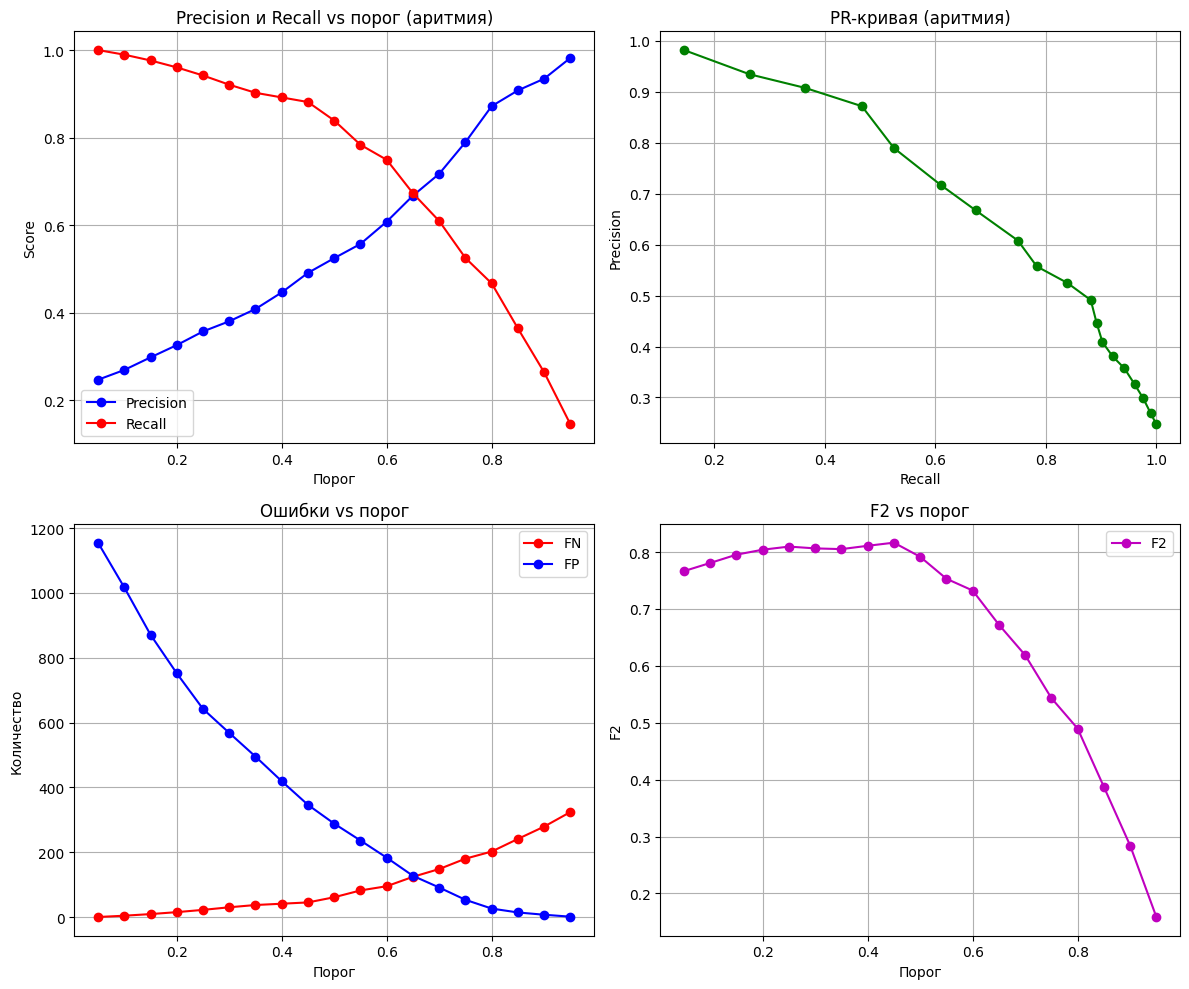

In [16]:
rf = RandomForestClassifier(random_state=random_state)
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [12, 18, 24],
    "min_samples_split": [10, 30, 80],
    "min_samples_leaf": [5, 15, 40],
    "max_features": [0.6, "sqrt"],
    "class_weight": [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}],
}
gs_rf = GridSearchCV(rf, param_grid_rf, scoring=f2_scorer, cv=cv, n_jobs=-1, verbose=1)
gs_rf.fit(X_train_scaled, y_train)
best_rf, best_rf_thr_model, thr_df_rf, thr_rf = report_model(gs_rf, "RandomForest")

## Градиентный бустинг: XGBoost

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 1, 'scale_pos_weight': 8, 'subsample': 0.8}
Лучший средний F2 (CV на train): 0.8055
Таблица порогов (1 = аритмия):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2442  1.0000 0.7637 1173 379   0   15
      0.10     0.2678  1.0000 0.7853 1036 379   0  152
      0.15     0.3037  0.9842 0.8041  855 373   6  333
      0.20     0.3312  0.9604 0.8071  735 364  15  453
      0.25     0.3622  0.9393 0.8102  627 356  23  561
      0.30     0.3913  0.9208 0.8111  543 349  30  645
      0.35     0.4188  0.9050 0.8109  476 343  36  712
      0.40     0.4583  0.8997 0.8207  403 341  38  785
      0.45     0.4813  0.8839 0.8157  361 335  44  827
      0.50     0.5061  0.8707 0.8122  322 330  49  866
      0.55     0.5361  0.8417 0.7963  276 319  60  912
      0.60     0.5610

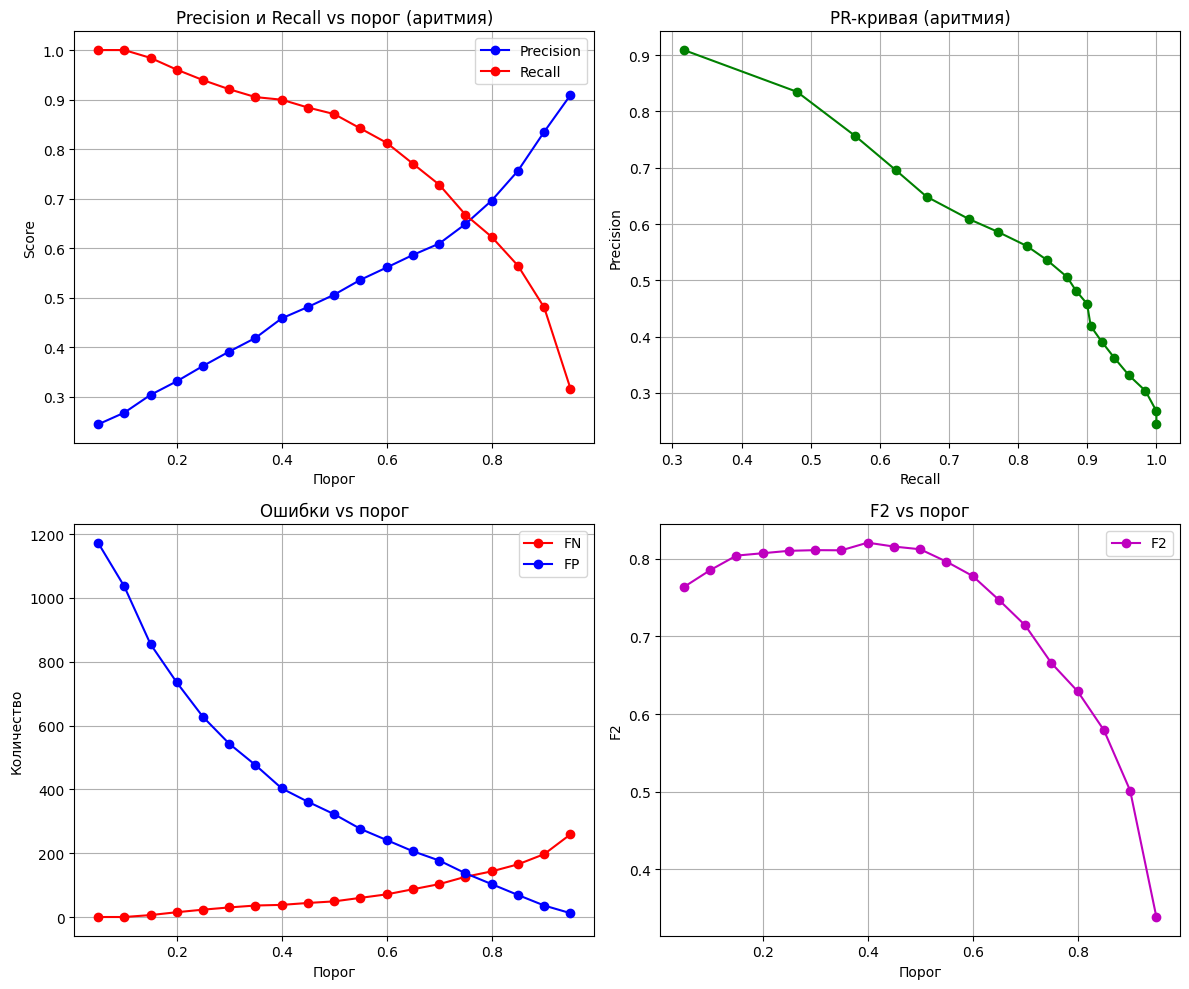

In [17]:
xgb = XGBClassifier(
    random_state=random_state,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
)
param_grid_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "reg_lambda": [1, 5],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "scale_pos_weight": [2.5, 3.5, 5, 8],  # ~баланс и сильнее — под F-beta
}
gs_xgb = GridSearchCV(xgb, param_grid_xgb, scoring=f2_scorer, cv=cv, n_jobs=-1, verbose=1)
gs_xgb.fit(X_train_scaled, y_train)
best_xgb_model, best_xgb_thr_model, thr_df_xgb, thr_xgb = report_model(gs_xgb, "XGBoost")

## Градиентный бустинг: CatBoost

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Лучшие параметры: {'class_weights': [1, 8], 'depth': 6, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.05}
Лучший средний F2 (CV на train): 0.7932
Таблица порогов (1 = аритмия):
 threshold  precision  recall     f2   fp  tp  fn   tn
      0.05     0.2507  1.0000 0.7699 1133 379   0   55
      0.10     0.2783  0.9921 0.7896  975 376   3  213
      0.15     0.3070  0.9631 0.7935  824 365  14  364
      0.20     0.3425  0.9525 0.8085  693 361  18  495
      0.25     0.3855  0.9420 0.8231  569 357  22  619
      0.30     0.4109  0.9182 0.8173  499 348  31  689
      0.35     0.4393  0.9077 0.8202  439 344  35  749
      0.40     0.4725  0.8839 0.8131  374 335  44  814
      0.45     0.4939  0.8602 0.8008  334 326  53  854
      0.50     0.5213  0.8391 0.7908  292 318  61  896
      0.55     0.5491  0.7968 0.7624  248 302  77  940
      0.60     0.5720  0.7652 0.7402  217 290  89  971
      0.65     0.6135  0.7414 0.7263

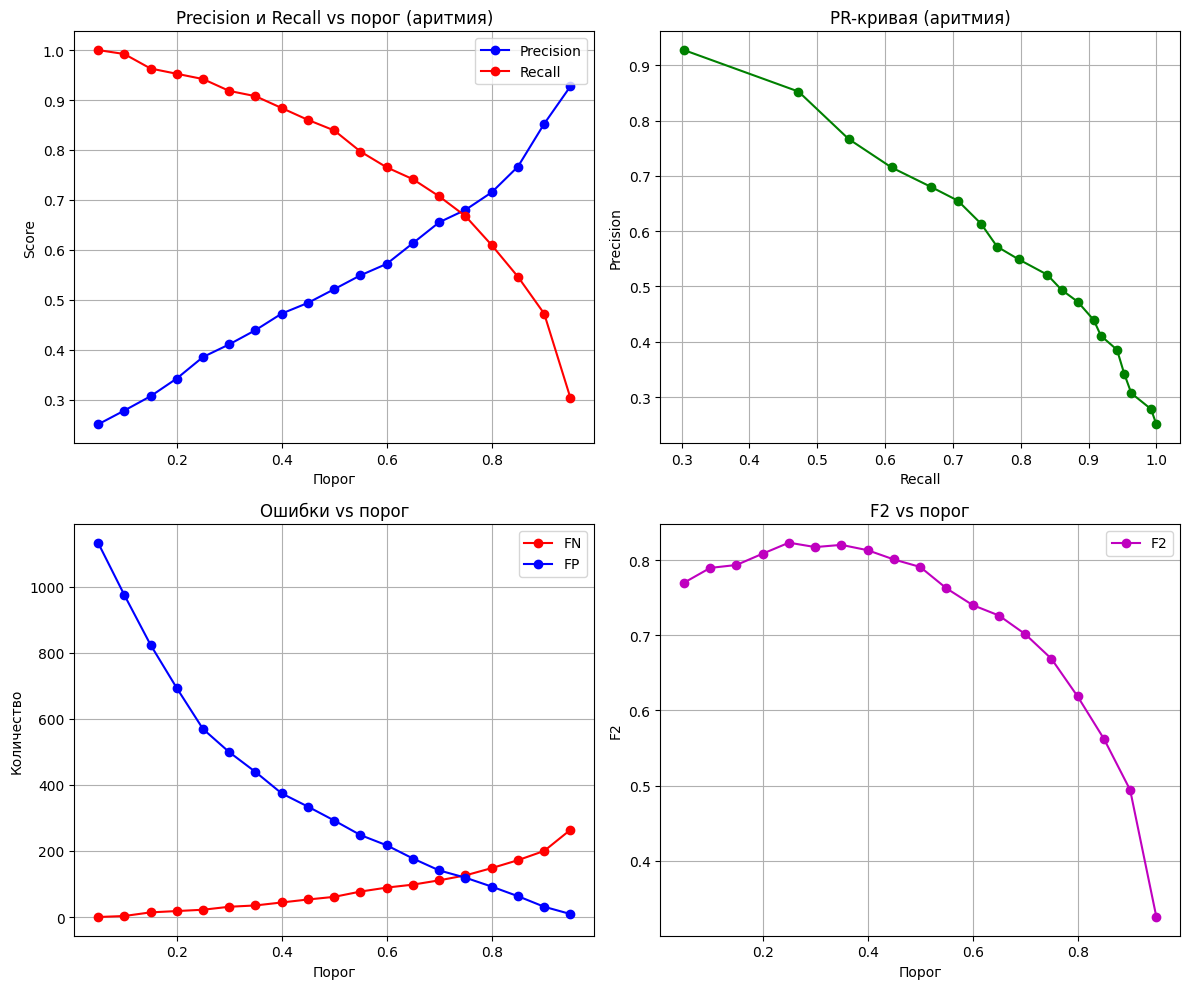

In [18]:
cat = CatBoostClassifier(random_state=random_state, verbose=0)
param_grid_cat = {
    "iterations": [300],
    "depth": [6, 8],
    "learning_rate": [0.05, 0.1],
    "l2_leaf_reg": [3, 7],
    "class_weights": [[1, 2], [1, 3], [1, 5], [1, 8]],
}
gs_cat = GridSearchCV(cat, param_grid_cat, scoring=f2_scorer, cv=cv, n_jobs=-1, verbose=1)
gs_cat.fit(X_train_scaled, y_train)
best_cat, best_cat_thr_model, thr_df_cat, thr_cat = report_model(gs_cat, "CatBoost")

## Сравнение моделей по валидации и тесту

In [19]:
display(results_summary.sort_values("test_f2", ascending=False).round(4))

,model,cv_train_f2,val_f2,test_f2,val_recall,test_recall,threshold
4,CatBoost,0.7932,0.8231,0.8245,0.9420,0.9493,0.25
3,XGBoost,0.8055,0.8207,0.8079,0.8997,0.8901,0.40
0,LogisticRegression,0.7609,0.7968,0.7887,0.8918,0.8837,0.35
2,RandomForest,0.7893,0.8164,0.7877,0.8813,0.8520,0.45
1,DecisionTree,0.7816,0.7716,0.7716,0.8602,0.8647,0.25


## Важность признаков (CatBoost)

,feature,importance
5,II_SNR_dB,7.242240
37,I_wavelet_E5,6.177088
15,V1_RMSSD,5.686048
38,I_wavelet_entropy,5.394190
4,II_wavelet_entropy,5.209626
0,heart_axis_norm,4.808281
13,AVL_SNR_dB,3.926315
9,AVR_STFT_energy,3.921904
2,age,3.584947
10,AVR_SNR_dB,3.232313


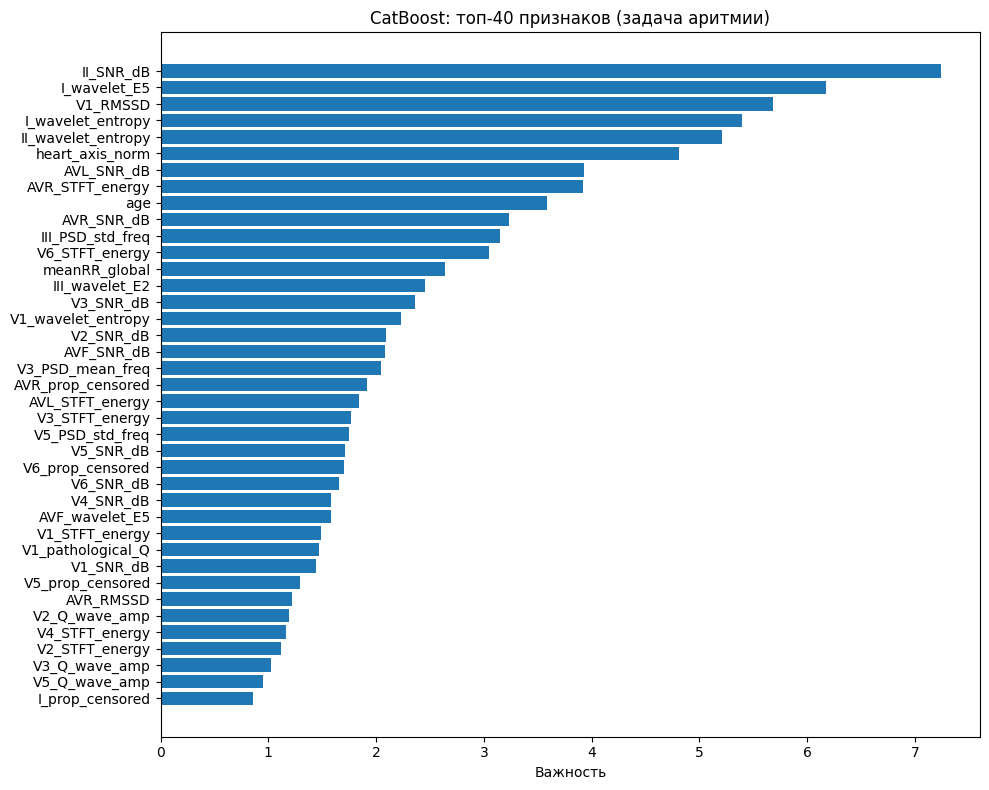

In [22]:
imp = pd.DataFrame({"feature": X.columns, "importance": best_cat.feature_importances_})
imp = imp.sort_values("importance", ascending=False).head(40)
display(imp)

plt.figure(figsize=(10, 8))
plt.barh(imp["feature"], imp["importance"])
plt.xlabel("Важность")
plt.title("CatBoost: топ-40 признаков (задача аритмии)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Сохранение лучшей модели (по F2 на тесте)

In [23]:
import joblib

best_row = results_summary.loc[results_summary["test_f2"].idxmax()]
print("Лучшая по test_f2:", best_row["model"])
pack = {
    "target": TARGET_COL,
    "model_label": best_row["model"],
    "results_summary": results_summary,
    "scaler": scaler,
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "feature_names": list(X.columns),
}

name = str(best_row["model"]).replace(" ", "_")
if name == "LogisticRegression":
    pack["classifier"] = best_lr_thr_model
    pack["raw_estimator"] = best_lr
elif name == "DecisionTree":
    pack["classifier"] = best_dt_thr_model
    pack["raw_estimator"] = best_dt
elif name == "RandomForest":
    pack["classifier"] = best_rf_thr_model
    pack["raw_estimator"] = best_rf
elif name == "XGBoost":
    pack["classifier"] = best_xgb_thr_model
    pack["raw_estimator"] = best_xgb_model
elif name == "CatBoost":
    pack["classifier"] = best_cat_thr_model
    pack["raw_estimator"] = best_cat
else:
    raise ValueError(name)

joblib.dump(pack, f"best_arrhythmia_model_{name}.joblib")
print("Сохранено:", f"best_arrhythmia_model_{name}.joblib")

Лучшая по test_f2: CatBoost
Сохранено: best_arrhythmia_model_CatBoost.joblib
